In [1]:
import pandas as pd

dataframes = []

files = []

for year in range(2023,2024):
  for month in range(1,13):
    if month < 10:
      month = "0"+str(month)
    else :
      month = str(month)
    files.append("./dataframe/NVDA_"+str(year)+"-"+month+".csv")
for file_name in files:
    df = pd.read_csv(file_name)
    dataframes.append(df)


combined_df = pd.concat(dataframes, ignore_index=True)

combined_df = combined_df.sort_values(by="time")

# Import Data Analyser Class and Utility Classes

In [2]:
from dataAnalyser import *
from utility import *
from datetime import datetime
import torch
import numpy as np

In [3]:
quotes = []

for index, row in combined_df.iterrows():
    quote = Quote(row["openPrice"],row["closePrice"],row["highPrice"],row["lowPrice"],datetime.strptime(row["time"],"%Y-%m-%d %H:%M:%S"),row["volume"])
    quotes.append(quote)

In [4]:
NASDAQ_HOUR_A_DAY = 6
SMA_EMA_PERIOD = 20*NASDAQ_HOUR_A_DAY #en heures
K_PERIOD = 14*NASDAQ_HOUR_A_DAY  #en heures
D_PERIOD = 3*NASDAQ_HOUR_A_DAY #en heures

dataAnalyser = DataAnalyser("NVDA")

data = []
target = []

for k in range(len(quotes)-1):
        quote = quotes[k]
        nextQuote = quotes[k+1]
        dataAnalyser.addQuote(quote)
        print(quote)

        if k+1 >= SMA_EMA_PERIOD: #on attend d'avoir au moins 20 jours de données pour commencer à calculer la moyenne mobile
            dataAnalyser.setStandard(SMA_EMA_PERIOD)
            #print("set standard")
        if k+1 >= K_PERIOD: #on attend d'avoir au moins 14 jours de données pour commencer à calculer l'oscillateur stochastique
            dataAnalyser.setStochastique(K_PERIOD)
            #print("set oscillateur stochastique")
        if dataAnalyser.getOscillateurStochastiqueLen() >= D_PERIOD: #on attend d'avoir au moins 3 jours de données pour commencer à calculer la moyenne mobile de l'oscillateur stochastique
            dataAnalyser.setSMAStochastique(D_PERIOD)
            #print("set SMA oscillateur stochastique")
        if dataAnalyser.getOscillateurStochastiqueSMALen() < D_PERIOD or k+1 < SMA_EMA_PERIOD:
            continue
        
        

        os = dataAnalyser.getOscillateurStochastique(dataAnalyser.getOscillateurStochastiqueLen()-1).value
        osSMA = dataAnalyser.getOscillateurStochastiqueSMA(dataAnalyser.getOscillateurStochastiqueSMALen()-1).value
        ema = dataAnalyser.getEMA(dataAnalyser.getEMALen()-1).value
        sma = dataAnalyser.getSMA(dataAnalyser.getSMALen()-1).value
        closePrice = quote.closePrice
        openPrice = quote.openPrice
        highPrice = quote.highPrice
        lowPrice = quote.lowPrice
        volume = quote.volume
        #data.append(torch.tensor([openPrice,highPrice,lowPrice,closePrice,sma,ema,osSMA,os,volume]))
        data.append(torch.tensor([openPrice,highPrice,lowPrice,closePrice,sma,ema,volume]))
        target.append(torch.tensor([nextQuote.closePrice, nextQuote.highPrice, nextQuote.lowPrice]))
        print(f"\tCreating dataset progress: {int((k+1)/len(quotes)*100)}%", end="\r")

# Normalisation des données

In [5]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = torch.tensor(np.array(data))
target = torch.tensor(np.array(target))
#to_normalize_data = data[:,:6] #take the first 6 columns
#to_normalize_volume = data[:,8].reshape(-1, 1) #take the volume column
os_data = data[:,6:8]

scaler_volume = MinMaxScaler()
scaler_data = MinMaxScaler()

normalized_input = torch.tensor(scaler_data.fit_transform(data))
#normalized_volume = torch.tensor(scaler_volume.fit_transform(to_normalize_volume))

#normalized_input = torch.cat((normalized_data, os_data, normalized_volume),1)
normalized_target = torch.tensor(scaler_data.fit_transform(target))



# Création dataset

In [6]:
from model import *

dataset = GeneralDataset(data=normalized_input, target=normalized_target, train_ratio=0.7, test_ratio=0.2)

In [8]:
import torch.optim as optim
import matplotlib.pyplot as plt

device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )

print(f"Using {device} device")

model = TradingModel(input_size=7, dropout=0.2, hidden_size=300).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')

test_loss =0.0
val_loss = 0.0

output_plot = []
target_plot = []

train_dataset = dataset.getTrainDataset()
test_dataset = dataset.getTestDataset()
val_dataset = dataset.getValidationDataset()

train_loader = create_batches(train_dataset,32,1)
test_loader = create_batches(test_dataset,32,1)
val_loader = create_batches(val_dataset,32,1)

num_epochs = 15
model.train(True)
for epoch in range(num_epochs):
    running_loss = 0.
    for i in range(len(train_loader[0])):

        inputs = train_loader[0][i]
        labels = train_loader[1][i]

        inputs = inputs.to(torch.float32)
        labels = labels.to(torch.float32)

        inputs = inputs.unsqueeze(1).to(device)
        labels = labels.to(device)
        output = model(inputs)
        if epoch == 14 and (i == 3 or i ==4):
            print(inputs)
            print(output)
            print(labels)

        loss = loss_fn(output, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch + 1}, iter {i + 1}: {running_loss / 100}")
    scheduler.step(running_loss)

Using cpu device
Epoch 1, iter 2680: 0.030817738038967944
Epoch 2, iter 2680: 0.04780947995141105
Epoch 3, iter 2680: 0.03494675920555892


KeyboardInterrupt: 

# Validation

[[201.64968547 204.73863807 199.79227823]
 [201.7816644  204.61632951 199.85071659]
 [200.01687826 202.32348046 197.75815781]
 ...
 [209.68332131 211.82925732 207.82058778]
 [209.45730066 211.5615839  207.36322242]
 [211.57042866 213.30234131 209.31705392]]


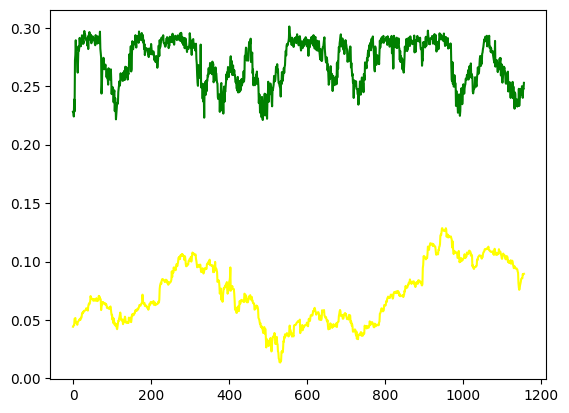

In [ ]:
predicted = []
target = []

for i in range(len(val_loader[0])):
    inputs = train_loader[0][i]
    labels = train_loader[1][i]
    inputs = inputs.to(torch.float32)
    labels = labels.to(torch.float32)
    inputs = inputs.unsqueeze(1).to(device)
    labels = labels.to(device)
    output = model(inputs)

    predicted.append(output[-1].cpu().detach())
    target.append(labels[-1].cpu().detach())

    loss = loss_fn(output, labels)
    val_loss += loss.item()

time = np.arange(0, len(predicted))

predicted = torch.tensor(np.array(predicted))
target = torch.tensor(np.array(target))

denormalized_predicted = scaler_data.inverse_transform(predicted)
denormalized_target = scaler_data.inverse_transform(target)

print(denormalized_predicted)

plt.plot(time,predicted[:,0],'-', color='green')
plt.plot(time,target[:,0],'-', color='yellow')

#plt.plot(time,denormalized_predicted[:,0],'-', color='blue')
#plt.plot(time,denormalized_target[:,0],'-', color='red')
plt.show()
